# Affine-Shift Experiment: Leroux CAR vs Precision P-spline SDM-CAR

The data are generated from a **true Leroux spatial field** on the true rook-lattice Laplacian. Both fitted models use the same deliberately warped operator,

$$
\mu_1 = 0,
\qquad
\mu_i = A + \lambda_i,
\quad i\ge 2,
$$

with `AFFINE_SCALE_B = 1.00` and the true eigenvectors retained.

The notebook now compares:

1. **Leroux CAR on the warped operator** — the classical parametric baseline.
2. **Positive-precision P-spline SDM-CAR on the same warped operator** — the flexible spectral model.

It keeps the original P-spline representational-capacity check and adds the analogous direct Leroux check. This separates:

* **family capacity:** can the model match the known target spectrum when the target is supplied directly?
* **statistical recovery:** can the model recover a useful spectrum from one noisy realization with a centered holdout block?
* **prediction:** which model reconstructs the held-out latent field better?

The critical positive-mode shift is

$$
A_{\mathrm{critical}}=

\frac{1-\rho_0}{\rho_0}.
$$

For $A>A_{\mathrm{critical}}$, the target positive-mode precision cannot be represented exactly by an ordinary Leroux model on the warped eigenvalues, whereas the P-spline is allowed to bend away from the Leroux affine-precision family.


## 1. Imports and project path

In [6]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import sys
import math
from pathlib import Path

import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import torch

from IPython.display import display

ROOT = Path(
    r"C:\Users\pd006\Desktop\internship_search\sdm-car"
).resolve()

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from sdmcar.filters import (
    LerouxCARFilterFullVI,
    PositivePrecisionPSplineFullVI,
)
from sdmcar.models_holdout import SpectralCAR_HoldoutVI

torch.set_default_dtype(torch.double)
DEVICE = torch.device("cpu")

print("Project root:", ROOT)
print("Device:", DEVICE)


Project root: C:\Users\pd006\Desktop\internship_search\sdm-car
Device: cpu


## 2. Locked configuration

In [49]:
SEED = 111

N_ROWS = 20
N_COLS = 20
N = N_ROWS * N_COLS

TAU2_TRUE = 0.70
RHO_TRUE = 0.92
BETA_TRUE = 0.0
SIGMA2_TRUE = 0.15

HOLDOUT_SIDE = 10

# Change only A when studying misspecification difficulty.
AFFINE_SHIFT_A = 0.0
AFFINE_SCALE_B = 1.00

FIX_SIGMA2 = True
NUM_MC = 8
PRED_MC = 512
GRAD_CLIP = 10.0

# Likelihood-based VI.
LEROUX_ITERS = 3000
LEROUX_LR = 1e-3

PSPLINE_ITERS = 6000
PSPLINE_LR = 3e-4

# Direct target-spectrum fits.
DIRECT_LEROUX_ITERS = 3000
DIRECT_LEROUX_LR = 1e-2

DIRECT_PSPLINE_ITERS = 4000
DIRECT_PSPLINE_LR = 2e-2

# Fixed, truth-independent initializations used for every A and seed.
INIT_LEROUX_TAU2 = 0.50
INIT_LEROUX_RHO = 0.80

INIT_Q_LEFT = 0.20
INIT_Q_RIGHT = 5.00

CURVATURE_PRIOR_STD = 0.50

PSPLINE_KWARGS = {
    "degree": 3,
    "n_internal_knots": 4,
    "prior_std_log_q": 3.0,
    "prior_std_d2": CURVATURE_PRIOR_STD,
    "log_std_log_q": -3.0,
    "log_std_d2": -3.0,
    "init_d2": 0.0,
    "log_q_min": -20.0,
    "log_q_max": 20.0,
}

np.random.seed(SEED)
torch.manual_seed(SEED)

A_CRITICAL = (1.0 - RHO_TRUE) / RHO_TRUE

print("Nodes:", N)
print("Seed:", SEED)
print("Affine shift A:", AFFINE_SHIFT_A)
print("Affine scale B:", AFFINE_SCALE_B)
print("Curvature prior SD:", PSPLINE_KWARGS["prior_std_d2"])
print(f"Theoretical Leroux boundary: {A_CRITICAL:.6f}")
print(
    "Regime:",
    "inside exact Leroux family"
    if AFFINE_SHIFT_A < A_CRITICAL
    else "outside exact Leroux family",
)


Nodes: 400
Seed: 111
Affine shift A: 0.0
Affine scale B: 1.0
Curvature prior SD: 0.5
Theoretical Leroux boundary: 0.086957
Regime: inside exact Leroux family


## 3. True rook graph and warped eigenvalues

In [50]:
def node_index(row, col):
    return row * N_COLS + col


def build_rook_adjacency():
    W = np.zeros((N, N), dtype=float)

    for row in range(N_ROWS):
        for col in range(N_COLS):
            i = node_index(row, col)

            if col + 1 < N_COLS:
                j = node_index(row, col + 1)
                W[i, j] = W[j, i] = 1.0

            if row + 1 < N_ROWS:
                j = node_index(row + 1, col)
                W[i, j] = W[j, i] = 1.0

    np.fill_diagonal(W, 0.0)
    return W


def graph_laplacian(W):
    degree = W.sum(axis=1)
    L = np.diag(degree) - W
    return 0.5 * (L + L.T)


def affine_shift_positive_modes(
    lam,
    shift,
    scale=1.0,
    zero_tolerance=1e-8,
):
    if shift < 0.0:
        raise ValueError("shift must be nonnegative.")
    if scale <= 0.0:
        raise ValueError("scale must be positive.")

    lam = np.asarray(lam, dtype=float)
    warped = np.zeros_like(lam)
    positive = lam > zero_tolerance
    warped[positive] = shift + scale * lam[positive]
    return warped


W_true = build_rook_adjacency()
L_true = graph_laplacian(W_true)

lam_true, U_true = np.linalg.eigh(L_true)
lam_true = np.clip(lam_true, 0.0, None)

lam_warp = affine_shift_positive_modes(
    lam_true,
    shift=AFFINE_SHIFT_A,
    scale=AFFINE_SCALE_B,
)

# Controlled experiment: eigenvectors remain correct.
U_warp = U_true.copy()

positive_true_mask = lam_true > 1e-8
positive_warp_mask = lam_warp > 1e-8

print("Undirected edges:", np.count_nonzero(W_true) // 2)
print("True eigenvalue range:", (lam_true.min(), lam_true.max()))
print("Warped eigenvalue range:", (lam_warp.min(), lam_warp.max()))
print(
    "Smallest positive true eigenvalue:",
    lam_true[positive_true_mask].min(),
)
print(
    "Smallest positive warped eigenvalue:",
    lam_warp[positive_warp_mask].min(),
)

Undirected edges: 760
True eigenvalue range: (np.float64(5.337428614855639e-16), np.float64(7.950753362380551))
Warped eigenvalue range: (np.float64(0.0), np.float64(7.950753362380551))
Smallest positive true eigenvalue: 0.024623318809725358
Smallest positive warped eigenvalue: 0.024623318809725358


## 4. Simulate one Leroux spatial field

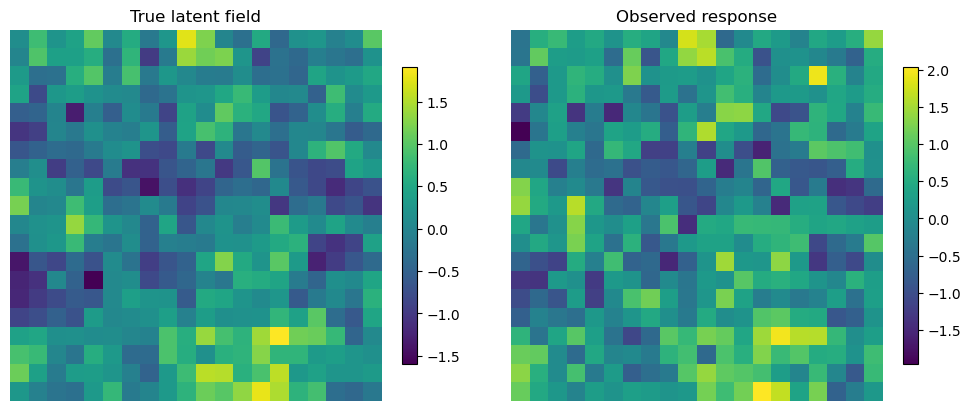

In [51]:
rng = np.random.default_rng(SEED)

# True covariance spectrum in the true eigenbasis.
F_true = (
    TAU2_TRUE
    / (
        (1.0 - RHO_TRUE)
        + RHO_TRUE * lam_true
    )
)

phi_true = U_true @ (
    np.sqrt(F_true)
    * rng.normal(size=N)
)

eta_true = BETA_TRUE + phi_true

y = eta_true + rng.normal(
    loc=0.0,
    scale=np.sqrt(SIGMA2_TRUE),
    size=N,
)

# Because U_warp = U_true, this is also the target modal
# covariance under the warped operator ordering.
target_covariance = F_true.copy()
target_precision = 1.0 / target_covariance

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 4),
    constrained_layout=True,
)

image_0 = axes[0].imshow(
    eta_true.reshape(N_ROWS, N_COLS)
)
axes[0].set_title("True latent field")
axes[0].axis("off")
fig.colorbar(image_0, ax=axes[0], shrink=0.8)

image_1 = axes[1].imshow(
    y.reshape(N_ROWS, N_COLS)
)
axes[1].set_title("Observed response")
axes[1].axis("off")
fig.colorbar(image_1, ax=axes[1], shrink=0.8)

plt.show()

## 5. Holdout block and tensors

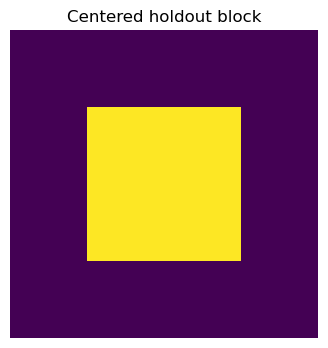

Training nodes: 300
Held-out nodes: 100


In [52]:
def centered_block_mask(side):
    mask = np.zeros((N_ROWS, N_COLS), dtype=bool)

    row_start = (N_ROWS - side) // 2
    col_start = (N_COLS - side) // 2

    mask[
        row_start:row_start + side,
        col_start:col_start + side,
    ] = True

    return mask.ravel()


def graph_tensors(lam, U):
    return (
        torch.tensor(
            np.clip(lam, 0.0, None),
            dtype=torch.double,
            device=DEVICE,
        ),
        torch.tensor(
            U,
            dtype=torch.double,
            device=DEVICE,
        ),
    )


test_mask = centered_block_mask(HOLDOUT_SIDE)
train_mask = ~test_mask

X_t = torch.ones(
    (N, 1),
    dtype=torch.double,
    device=DEVICE,
)

y_all_t = torch.tensor(
    y,
    dtype=torch.double,
    device=DEVICE,
)

is_holdout_t = torch.tensor(
    test_mask,
    dtype=torch.bool,
    device=DEVICE,
)

y_test_t = y_all_t[is_holdout_t].clone()

y_fit_t = y_all_t.clone()
y_fit_t[is_holdout_t] = torch.nan

prior_V0 = 10.0 * torch.eye(
    1,
    dtype=torch.double,
    device=DEVICE,
)

lam_warp_t, U_warp_t = graph_tensors(
    lam_warp,
    U_warp,
)

plt.figure(figsize=(4.5, 4))
plt.imshow(test_mask.reshape(N_ROWS, N_COLS))
plt.title("Centered holdout block")
plt.axis("off")
plt.show()

print("Training nodes:", int(train_mask.sum()))
print("Held-out nodes:", int(test_mask.sum()))

## 6. Filter factories

Both likelihood fits use the **same warped eigenvalues and eigenvectors**. The only difference is the spectral family.

The Leroux initialization below is fixed and truth-independent. The project `LerouxCARFilterFullVI` itself is otherwise used unchanged.


In [53]:
def rho_to_raw(rho, rho_eps=1e-4):
    """Invert rho = (1-rho_eps) * sigmoid(rho_raw)."""
    probability = rho / (1.0 - rho_eps)

    if not 0.0 < probability < 1.0:
        raise ValueError(
            "rho is incompatible with rho_eps."
        )

    return math.log(
        probability
        / (1.0 - probability)
    )


def make_leroux_filter():
    return LerouxCARFilterFullVI(
        mu_log_tau2=math.log(INIT_LEROUX_TAU2),
        log_std_log_tau2=-3.0,
        mu_rho_raw=rho_to_raw(INIT_LEROUX_RHO),
        log_std_rho_raw=-3.0,
        fixed_rho=None,
        rho_eps=1e-4,
    ).to(DEVICE)


def make_precision_spline_filter(lam_t):
    return PositivePrecisionPSplineFullVI(
        lam_max=float(lam_t.max().item()),
        mu_log_q_left=math.log(INIT_Q_LEFT),
        mu_log_q_right=math.log(INIT_Q_RIGHT),
        **PSPLINE_KWARGS,
    ).to(DEVICE)


leroux_check = make_leroux_filter()
filter_check = make_precision_spline_filter(lam_warp_t)

print("Leroux initialization:")
tau2_init, rho_init_vec = leroux_check.mean_params()
print("  tau2 =", float(tau2_init.cpu()))
print("  rho  =", float(rho_init_vec[0].cpu()))

print("\nP-spline structure:")
print("  basis functions J:", filter_check.J)
print("  second-difference parameters K:", filter_check.K)


Leroux initialization:
  tau2 = 0.5
  rho  = 0.8

P-spline structure:
  basis functions J: 8
  second-difference parameters K: 6


## 7. Direct representational-capacity check

These fits see the **known target precision** and therefore do **not** measure statistical recovery.

They answer two separate family-capacity questions:

- How closely can an ordinary Leroux spectrum on the warped eigenvalues reproduce the target?
- How closely can the positive-precision P-spline reproduce the same target?

For the P-spline, only the endpoint means and second-difference means are optimized. For Leroux, only the variational means of \(\log\tau^2\) and \(\rho_{\rm raw}\) are optimized.


In [54]:
def direct_filter_theta(filter_module):
    theta = {
        "log_q_left": filter_module.mu_log_q_endpoints[0:1],
        "log_q_right": filter_module.mu_log_q_endpoints[1:2],
    }

    for j in range(filter_module.K):
        theta[f"d2_{j}_raw"] = filter_module.mu_d2[j:j + 1]

    return theta


def direct_leroux_theta(filter_module):
    return {
        "log_tau2": filter_module.mu_log_tau2.reshape(1),
        "rho_raw": filter_module.mu_rho_raw.reshape(1),
    }


def log_spectrum_rmse(estimated, target, mask=None):
    estimated = np.asarray(estimated, dtype=float)
    target = np.asarray(target, dtype=float)

    if mask is not None:
        estimated = estimated[mask]
        target = target[mask]

    estimated = np.clip(estimated, 1e-12, None)
    target = np.clip(target, 1e-12, None)

    return float(
        np.sqrt(
            np.mean(
                (
                    np.log(estimated)
                    - np.log(target)
                ) ** 2
            )
        )
    )


q_target_t = torch.tensor(
    target_precision,
    dtype=torch.double,
    device=DEVICE,
)

# ---------------------------------------------------------
# Direct Leroux target fit
# ---------------------------------------------------------
direct_leroux = make_leroux_filter()

direct_leroux_optimizer = torch.optim.Adam(
    [
        direct_leroux.mu_log_tau2,
        direct_leroux.mu_rho_raw,
    ],
    lr=DIRECT_LEROUX_LR,
)

direct_leroux_loss_history = []

for iteration in range(1, DIRECT_LEROUX_ITERS + 1):
    direct_leroux_optimizer.zero_grad(set_to_none=True)

    theta_direct_leroux = direct_leroux_theta(
        direct_leroux
    )

    F_direct_leroux_t = direct_leroux.spectrum(
        lam_warp_t,
        theta_direct_leroux,
    )

    q_direct_leroux_t = 1.0 / F_direct_leroux_t.clamp_min(
        1e-12
    )

    direct_leroux_loss = torch.mean(
        (
            torch.log(q_direct_leroux_t)
            - torch.log(q_target_t)
        ) ** 2
    )

    direct_leroux_loss.backward()

    torch.nn.utils.clip_grad_norm_(
        [
            direct_leroux.mu_log_tau2,
            direct_leroux.mu_rho_raw,
        ],
        max_norm=10.0,
    )

    direct_leroux_optimizer.step()

    direct_leroux_loss_history.append(
        float(direct_leroux_loss.detach().cpu())
    )

    if iteration == 1 or iteration % 500 == 0:
        print(
            f"Direct Leroux {iteration:4d} | "
            f"log-MSE={direct_leroux_loss_history[-1]:.8f}"
        )


with torch.no_grad():
    theta_direct_leroux = direct_leroux_theta(
        direct_leroux
    )

    F_direct_leroux = (
        direct_leroux
        .spectrum(
            lam_warp_t,
            theta_direct_leroux,
        )
        .detach()
        .cpu()
        .numpy()
    )

q_direct_leroux = 1.0 / np.clip(
    F_direct_leroux,
    1e-12,
    None,
)

direct_leroux_tau2, direct_leroux_rho_vec = (
    direct_leroux.mean_params()
)

# ---------------------------------------------------------
# Direct P-spline target fit
# ---------------------------------------------------------
direct_filter = make_precision_spline_filter(
    lam_warp_t
)

direct_pspline_optimizer = torch.optim.Adam(
    [
        direct_filter.mu_log_q_endpoints,
        direct_filter.mu_d2,
    ],
    lr=DIRECT_PSPLINE_LR,
)

direct_pspline_loss_history = []

for iteration in range(1, DIRECT_PSPLINE_ITERS + 1):
    direct_pspline_optimizer.zero_grad(set_to_none=True)

    theta_direct = direct_filter_theta(direct_filter)

    q_direct_t = (
        direct_filter.precision_from_unconstrained(
            lam_warp_t,
            theta_direct,
        )
    )

    direct_pspline_loss = torch.mean(
        (
            torch.log(q_direct_t)
            - torch.log(q_target_t)
        ) ** 2
    )

    direct_pspline_loss.backward()

    torch.nn.utils.clip_grad_norm_(
        [
            direct_filter.mu_log_q_endpoints,
            direct_filter.mu_d2,
        ],
        max_norm=10.0,
    )

    direct_pspline_optimizer.step()

    direct_pspline_loss_history.append(
        float(direct_pspline_loss.detach().cpu())
    )

    if iteration == 1 or iteration % 500 == 0:
        print(
            f"Direct P-spline {iteration:4d} | "
            f"log-MSE={direct_pspline_loss_history[-1]:.8f}"
        )


with torch.no_grad():
    theta_direct = direct_filter_theta(direct_filter)

    q_direct_fit = (
        direct_filter
        .precision_from_unconstrained(
            lam_warp_t,
            theta_direct,
        )
        .detach()
        .cpu()
        .numpy()
    )

F_direct_fit = 1.0 / np.clip(
    q_direct_fit,
    1e-12,
    None,
)

direct_summary = direct_filter.shrinkage_summary()

left = np.argmin(lam_warp)
right = np.argmax(lam_warp)

direct_metrics = pd.DataFrame(
    [
        {
            "model": "Direct Leroux",
            "log_spectrum_rmse_all": log_spectrum_rmse(
                F_direct_leroux,
                target_covariance,
            ),
            "log_spectrum_rmse_positive": log_spectrum_rmse(
                F_direct_leroux,
                target_covariance,
                positive_warp_mask,
            ),
            "q_left": q_direct_leroux[left],
            "q_right": q_direct_leroux[right],
            "d2_l2": np.nan,
        },
        {
            "model": "Direct P-spline",
            "log_spectrum_rmse_all": log_spectrum_rmse(
                F_direct_fit,
                target_covariance,
            ),
            "log_spectrum_rmse_positive": log_spectrum_rmse(
                F_direct_fit,
                target_covariance,
                positive_warp_mask,
            ),
            "q_left": q_direct_fit[left],
            "q_right": q_direct_fit[right],
            "d2_l2": float(
                direct_summary["d2_l2"].cpu()
            ),
        },
        {
            "model": "Target",
            "log_spectrum_rmse_all": 0.0,
            "log_spectrum_rmse_positive": 0.0,
            "q_left": target_precision[left],
            "q_right": target_precision[right],
            "d2_l2": np.nan,
        },
    ]
)

display(direct_metrics)

print("Direct Leroux parameters:")
print(
    "  tau2 =",
    float(direct_leroux_tau2.detach().cpu()),
)
print(
    "  rho  =",
    float(direct_leroux_rho_vec[0].detach().cpu()),
)


Direct Leroux    1 | log-MSE=0.08911672
Direct Leroux  500 | log-MSE=0.00000000
Direct Leroux 1000 | log-MSE=0.00000000
Direct Leroux 1500 | log-MSE=0.00000000
Direct Leroux 2000 | log-MSE=0.00000000
Direct Leroux 2500 | log-MSE=0.00000000
Direct Leroux 3000 | log-MSE=0.00000000
Direct P-spline    1 | log-MSE=0.47174154
Direct P-spline  500 | log-MSE=0.00024631
Direct P-spline 1000 | log-MSE=0.00001634
Direct P-spline 1500 | log-MSE=0.00000360
Direct P-spline 2000 | log-MSE=0.00000100
Direct P-spline 2500 | log-MSE=0.00000024
Direct P-spline 3000 | log-MSE=0.00000005
Direct P-spline 3500 | log-MSE=0.00000001
Direct P-spline 4000 | log-MSE=0.00000000


,model,log_spectrum_rmse_all,log_spectrum_rmse_positive,q_left,q_right,d2_l2
0,Direct Leroux,2.997643e-16,2.016345e-16,0.114286,10.563847,NaN
1,Direct P-spline,3.406836e-05,3.371426e-05,0.114298,10.562793,0.001414
2,Target,0.000000e+00,0.000000e+00,0.114286,10.563847,NaN


Direct Leroux parameters:
  tau2 = 0.6999999999999998
  rho  = 0.9199999999999999


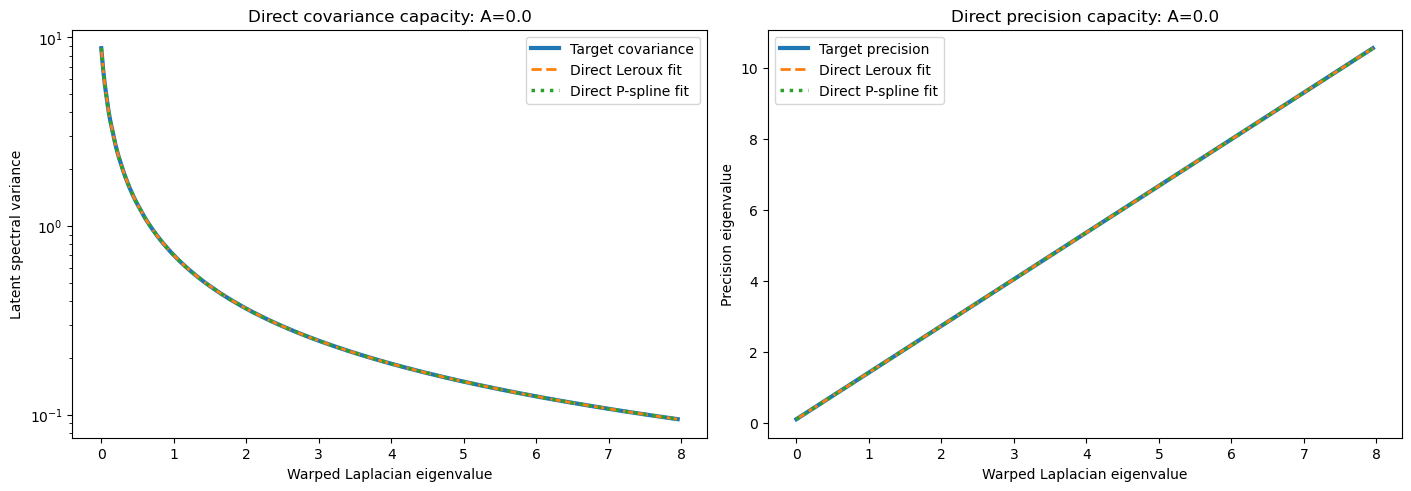

In [55]:
order = np.argsort(lam_warp)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 4.8),
    constrained_layout=True,
)

axes[0].plot(
    lam_warp[order],
    target_covariance[order],
    linewidth=3,
    label="Target covariance",
)
axes[0].plot(
    lam_warp[order],
    F_direct_leroux[order],
    linestyle="--",
    linewidth=2,
    label="Direct Leroux fit",
)
axes[0].plot(
    lam_warp[order],
    F_direct_fit[order],
    linestyle=":",
    linewidth=2.5,
    label="Direct P-spline fit",
)
axes[0].set_yscale("log")
axes[0].set_xlabel("Warped Laplacian eigenvalue")
axes[0].set_ylabel("Latent spectral variance")
axes[0].set_title(
    f"Direct covariance capacity: A={AFFINE_SHIFT_A}"
)
axes[0].legend()

axes[1].plot(
    lam_warp[order],
    target_precision[order],
    linewidth=3,
    label="Target precision",
)
axes[1].plot(
    lam_warp[order],
    q_direct_leroux[order],
    linestyle="--",
    linewidth=2,
    label="Direct Leroux fit",
)
axes[1].plot(
    lam_warp[order],
    q_direct_fit[order],
    linestyle=":",
    linewidth=2.5,
    label="Direct P-spline fit",
)
axes[1].set_xlabel("Warped Laplacian eigenvalue")
axes[1].set_ylabel("Precision eigenvalue")
axes[1].set_title(
    f"Direct precision capacity: A={AFFINE_SHIFT_A}"
)
axes[1].legend()

plt.show()


## 8. Likelihood-based Leroux and P-spline fits

Both models now use only the training observations and the **same warped operator**. This is the comparison that matters for the misspecification experiment.

No oracle model is fitted here: Leroux and P-spline both receive exactly the same

$$
(\mu, U_{\rm warp}).
$$


In [56]:
def fit_spectral_vi(
    *,
    label,
    lam_t,
    U_t,
    filter_module,
    iterations,
    learning_rate,
    seed,
):
    np.random.seed(seed)
    torch.manual_seed(seed)

    model = SpectralCAR_HoldoutVI(
        X=X_t,
        y=y_fit_t,
        lam=lam_t,
        U=U_t,
        filter_module=filter_module,
        is_holdout=is_holdout_t,
        prior_m0=None,
        prior_V0=prior_V0,
        mu_log_sigma2=math.log(SIGMA2_TRUE),
        log_std_log_sigma2=-2.3,
        num_mc=NUM_MC,
        fixed_sigma2=(
            SIGMA2_TRUE if FIX_SIGMA2 else None
        ),
        jitter=1e-8,
    ).to(DEVICE)

    optimizer = torch.optim.Adam(
        [
            parameter
            for parameter in model.parameters()
            if parameter.requires_grad
        ],
        lr=learning_rate,
    )

    history = []

    for iteration in range(1, iterations + 1):
        optimizer.zero_grad(set_to_none=True)

        elbo, _ = model.elbo()
        loss = -elbo

        if not torch.isfinite(loss):
            raise RuntimeError(
                f"Non-finite {label} loss "
                f"at iteration {iteration}."
            )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            GRAD_CLIP,
        )

        optimizer.step()
        history.append(float(elbo.detach().cpu()))

        if iteration % 500 == 0:
            recent = float(
                np.mean(history[-100:])
            )
            print(
                f"{label}: {iteration}/{iterations}, "
                f"recent ELBO={recent:.3f}"
            )

    torch.manual_seed(seed + 10_000)

    prediction = model.predict_vi_mc(
        num_mc=PRED_MC
    )

    metrics = model.score_predictions(
        y_test=y_test_t,
        prediction=prediction,
    )

    return {
        "label": label,
        "model": model,
        "prediction": prediction,
        "metrics": metrics,
        "history": history,
        "lam_t": lam_t,
        "U_t": U_t,
    }


leroux_result = fit_spectral_vi(
    label="Leroux VI",
    lam_t=lam_warp_t,
    U_t=U_warp_t,
    filter_module=make_leroux_filter(),
    iterations=LEROUX_ITERS,
    learning_rate=LEROUX_LR,
    seed=SEED,
)

pspline_result = fit_spectral_vi(
    label="P-spline VI",
    lam_t=lam_warp_t,
    U_t=U_warp_t,
    filter_module=make_precision_spline_filter(
        lam_warp_t
    ),
    iterations=PSPLINE_ITERS,
    learning_rate=PSPLINE_LR,
    seed=SEED,
)

print("Both likelihood fits complete.")


Leroux VI: 500/3000, recent ELBO=-24.961
Leroux VI: 1000/3000, recent ELBO=-24.290
Leroux VI: 1500/3000, recent ELBO=-23.899
Leroux VI: 2000/3000, recent ELBO=-23.544
Leroux VI: 2500/3000, recent ELBO=-23.508
Leroux VI: 3000/3000, recent ELBO=-23.411
P-spline VI: 500/6000, recent ELBO=-37.392
P-spline VI: 1000/6000, recent ELBO=-35.470
P-spline VI: 1500/6000, recent ELBO=-34.279
P-spline VI: 2000/6000, recent ELBO=-33.558
P-spline VI: 2500/6000, recent ELBO=-32.733
P-spline VI: 3000/6000, recent ELBO=-32.238
P-spline VI: 3500/6000, recent ELBO=-31.978
P-spline VI: 4000/6000, recent ELBO=-31.356
P-spline VI: 4500/6000, recent ELBO=-31.289
P-spline VI: 5000/6000, recent ELBO=-30.727
P-spline VI: 5500/6000, recent ELBO=-30.936
P-spline VI: 6000/6000, recent ELBO=-30.660
Both likelihood fits complete.


## 9. Prediction metrics

In [57]:
leroux_prediction_mean = (
    leroux_result["prediction"]["mean"]
    .detach()
    .cpu()
    .numpy()
)

pspline_prediction_mean = (
    pspline_result["prediction"]["mean"]
    .detach()
    .cpu()
    .numpy()
)


def latent_holdout_rmse(prediction_mean):
    return float(
        np.sqrt(
            np.mean(
                (
                    prediction_mean
                    - eta_true[test_mask]
                ) ** 2
            )
        )
    )


prediction_results = pd.DataFrame(
    [
        {
            "model": "Leroux CAR",
            "A": AFFINE_SHIFT_A,
            "test_y_rmse": float(
                leroux_result["metrics"]["rmse"]
            ),
            "test_y_mae": float(
                leroux_result["metrics"]["mae"]
            ),
            "test_eta_rmse": latent_holdout_rmse(
                leroux_prediction_mean
            ),
        },
        {
            "model": "Precision P-spline SDM-CAR",
            "A": AFFINE_SHIFT_A,
            "test_y_rmse": float(
                pspline_result["metrics"]["rmse"]
            ),
            "test_y_mae": float(
                pspline_result["metrics"]["mae"]
            ),
            "test_eta_rmse": latent_holdout_rmse(
                pspline_prediction_mean
            ),
        },
    ]
)

display(prediction_results)

eta_gain = (
    prediction_results.loc[
        prediction_results["model"] == "Leroux CAR",
        "test_eta_rmse",
    ].iloc[0]
    -
    prediction_results.loc[
        prediction_results["model"]
        == "Precision P-spline SDM-CAR",
        "test_eta_rmse",
    ].iloc[0]
)

print(
    "Latent-RMSE gain (Leroux - P-spline):",
    f"{eta_gain:.6f}",
)
print("Positive gain favors the P-spline.")


,model,A,test_y_rmse,test_y_mae,test_eta_rmse
0,Leroux CAR,0.0,0.745002,0.612909,0.563841
1,Precision P-spline SDM-CAR,0.0,0.743905,0.612320,0.562448


Latent-RMSE gain (Leroux - P-spline): 0.001393
Positive gain favors the P-spline.


## 10. Posterior spectra, Leroux parameters, and P-spline curvature

In [58]:
@torch.no_grad()
def plugin_spectrum(result):
    theta_mean = (
        result["model"]
        .filter
        .mean_unconstrained()
    )

    return (
        result["model"]
        .filter
        .spectrum(
            result["lam_t"],
            theta_mean,
        )
        .detach()
        .cpu()
        .numpy()
    )


@torch.no_grad()
def posterior_spectrum_precision_summary(
    result,
    draws=512,
    credible_level=0.95,
    seed=20_000,
):
    """
    Joint Monte Carlo summaries of covariance spectrum F
    and precision spectrum q=1/F.

    This reports E[F(theta)] and E[q(theta)] separately.
    In particular, E[q] is not computed as 1/E[F].
    """
    if not 0.0 < credible_level < 1.0:
        raise ValueError(
            "credible_level must lie between 0 and 1."
        )

    torch.manual_seed(seed)
    F_draws = []

    for _ in range(draws):
        theta = (
            result["model"]
            .filter
            .sample_unconstrained()
        )

        F = (
            result["model"]
            .filter
            .spectrum(
                result["lam_t"],
                theta,
            )
            .clamp_min(1e-12)
        )

        F_draws.append(F)

    F_draws = torch.stack(
        F_draws,
        dim=0,
    )
    q_draws = 1.0 / F_draws

    tail = (1.0 - credible_level) / 2.0

    def summarize(draws_t):
        return {
            "mean": draws_t.mean(dim=0),
            "lower": torch.quantile(
                draws_t,
                tail,
                dim=0,
            ),
            "upper": torch.quantile(
                draws_t,
                1.0 - tail,
                dim=0,
            ),
        }

    F_summary = summarize(F_draws)
    q_summary = summarize(q_draws)

    def to_numpy(x):
        return x.detach().cpu().numpy()

    return {
        "F_mean": to_numpy(F_summary["mean"]),
        "F_lower": to_numpy(F_summary["lower"]),
        "F_upper": to_numpy(F_summary["upper"]),
        "q_mean": to_numpy(q_summary["mean"]),
        "q_lower": to_numpy(q_summary["lower"]),
        "q_upper": to_numpy(q_summary["upper"]),
    }


@torch.no_grad()
def posterior_precision_components_summary(
    result,
    draws=512,
    credible_level=0.95,
    seed=20_002,
):
    """
    P-spline-only posterior summaries for:

        q_full(lambda; theta)
        q_affine(lambda; theta)
        log_correction(lambda; theta)
    """
    if not 0.0 < credible_level < 1.0:
        raise ValueError(
            "credible_level must lie between 0 and 1."
        )

    torch.manual_seed(seed)

    filt = result["model"].filter
    lam_t = result["lam_t"]

    q_full_draws = []
    q_affine_draws = []
    log_correction_draws = []

    for _ in range(draws):
        theta = filt.sample_unconstrained()

        q_full_draws.append(
            filt.precision_from_unconstrained(
                lam_t,
                theta,
            )
        )
        q_affine_draws.append(
            filt.affine_precision_from_unconstrained(
                lam_t,
                theta,
            )
        )
        log_correction_draws.append(
            filt.correction_from_unconstrained(
                lam_t,
                theta,
            )
        )

    q_full_draws = torch.stack(q_full_draws, dim=0)
    q_affine_draws = torch.stack(q_affine_draws, dim=0)
    log_correction_draws = torch.stack(
        log_correction_draws,
        dim=0,
    )

    tail = (1.0 - credible_level) / 2.0

    def summarize(draws_t):
        return {
            "mean": draws_t.mean(dim=0),
            "lower": torch.quantile(
                draws_t,
                tail,
                dim=0,
            ),
            "upper": torch.quantile(
                draws_t,
                1.0 - tail,
                dim=0,
            ),
        }

    q_full_summary = summarize(q_full_draws)
    q_affine_summary = summarize(q_affine_draws)
    correction_summary = summarize(
        log_correction_draws
    )

    def to_numpy(x):
        return x.detach().cpu().numpy()

    return {
        "q_full_mean": to_numpy(q_full_summary["mean"]),
        "q_full_lower": to_numpy(q_full_summary["lower"]),
        "q_full_upper": to_numpy(q_full_summary["upper"]),
        "q_affine_mean": to_numpy(q_affine_summary["mean"]),
        "q_affine_lower": to_numpy(q_affine_summary["lower"]),
        "q_affine_upper": to_numpy(q_affine_summary["upper"]),
        "log_correction_mean": to_numpy(
            correction_summary["mean"]
        ),
        "log_correction_lower": to_numpy(
            correction_summary["lower"]
        ),
        "log_correction_upper": to_numpy(
            correction_summary["upper"]
        ),
    }


@torch.no_grad()
def posterior_leroux_parameter_summary(
    result,
    draws=2048,
    credible_level=0.95,
    seed=20_100,
):
    torch.manual_seed(seed)
    filt = result["model"].filter

    tau2_draws = []
    rho_draws = []

    for _ in range(draws):
        theta = filt.sample_unconstrained()
        constrained = filt._constrain(theta)

        tau2_draws.append(
            constrained["tau2"].reshape(())
        )
        rho_draws.append(
            constrained["rho"].reshape(())
        )

    tau2_draws = torch.stack(tau2_draws)
    rho_draws = torch.stack(rho_draws)

    tail = (1.0 - credible_level) / 2.0

    def one_summary(draws_t):
        return (
            float(draws_t.mean().cpu()),
            float(
                torch.quantile(
                    draws_t,
                    tail,
                ).cpu()
            ),
            float(
                torch.quantile(
                    draws_t,
                    1.0 - tail,
                ).cpu()
            ),
        )

    return {
        "tau2": one_summary(tau2_draws),
        "rho": one_summary(rho_draws),
    }


leroux_plugin = plugin_spectrum(leroux_result)
pspline_plugin = plugin_spectrum(pspline_result)

leroux_post = posterior_spectrum_precision_summary(
    leroux_result,
    draws=512,
    seed=20_001,
)

pspline_post = posterior_spectrum_precision_summary(
    pspline_result,
    draws=512,
    seed=20_002,
)

F_leroux_mean = leroux_post["F_mean"]
F_leroux_lower = leroux_post["F_lower"]
F_leroux_upper = leroux_post["F_upper"]
q_leroux_mean = leroux_post["q_mean"]
q_leroux_lower = leroux_post["q_lower"]
q_leroux_upper = leroux_post["q_upper"]

F_pspline_mean = pspline_post["F_mean"]
F_pspline_lower = pspline_post["F_lower"]
F_pspline_upper = pspline_post["F_upper"]
q_pspline_mean = pspline_post["q_mean"]
q_pspline_lower = pspline_post["q_lower"]
q_pspline_upper = pspline_post["q_upper"]

precision_components = (
    posterior_precision_components_summary(
        pspline_result,
        draws=512,
        credible_level=0.95,
        seed=20_003,
    )
)

q_pspline_affine_mean = precision_components[
    "q_affine_mean"
]
q_pspline_affine_lower = precision_components[
    "q_affine_lower"
]
q_pspline_affine_upper = precision_components[
    "q_affine_upper"
]

vi_log_correction_mean = precision_components[
    "log_correction_mean"
]
vi_log_correction_lower = precision_components[
    "log_correction_lower"
]
vi_log_correction_upper = precision_components[
    "log_correction_upper"
]

vi_shrinkage = (
    pspline_result["model"]
    .filter
    .shrinkage_summary()
)

leroux_param_summary = (
    posterior_leroux_parameter_summary(
        leroux_result,
        draws=2048,
        seed=20_100,
    )
)

parameter_table = pd.DataFrame(
    [
        {
            "parameter": "tau2",
            "truth_on_true_operator": TAU2_TRUE,
            "posterior_mean": leroux_param_summary["tau2"][0],
            "lower_95": leroux_param_summary["tau2"][1],
            "upper_95": leroux_param_summary["tau2"][2],
        },
        {
            "parameter": "rho",
            "truth_on_true_operator": RHO_TRUE,
            "posterior_mean": leroux_param_summary["rho"][0],
            "lower_95": leroux_param_summary["rho"][1],
            "upper_95": leroux_param_summary["rho"][2],
        },
    ]
)

print(
    "Leroux parameters are fitted on the warped operator; "
    "the truth column is only a reference."
)
display(parameter_table)

left = np.argmin(lam_warp)
right = np.argmax(lam_warp)

spectral_diagnostics = pd.DataFrame(
    [
        {
            "fit": "Direct Leroux",
            "log_spectrum_rmse_all": log_spectrum_rmse(
                F_direct_leroux,
                target_covariance,
            ),
            "log_spectrum_rmse_positive": log_spectrum_rmse(
                F_direct_leroux,
                target_covariance,
                positive_warp_mask,
            ),
            "q_left": q_direct_leroux[left],
            "q_right": q_direct_leroux[right],
            "d2_l2": np.nan,
        },
        {
            "fit": "Direct P-spline",
            "log_spectrum_rmse_all": log_spectrum_rmse(
                F_direct_fit,
                target_covariance,
            ),
            "log_spectrum_rmse_positive": log_spectrum_rmse(
                F_direct_fit,
                target_covariance,
                positive_warp_mask,
            ),
            "q_left": q_direct_fit[left],
            "q_right": q_direct_fit[right],
            "d2_l2": float(
                direct_summary["d2_l2"].cpu()
            ),
        },
        {
            "fit": "Likelihood Leroux posterior mean",
            "log_spectrum_rmse_all": log_spectrum_rmse(
                F_leroux_mean,
                target_covariance,
            ),
            "log_spectrum_rmse_positive": log_spectrum_rmse(
                F_leroux_mean,
                target_covariance,
                positive_warp_mask,
            ),
            "q_left": q_leroux_mean[left],
            "q_right": q_leroux_mean[right],
            "d2_l2": np.nan,
        },
        {
            "fit": "Likelihood P-spline posterior mean",
            "log_spectrum_rmse_all": log_spectrum_rmse(
                F_pspline_mean,
                target_covariance,
            ),
            "log_spectrum_rmse_positive": log_spectrum_rmse(
                F_pspline_mean,
                target_covariance,
                positive_warp_mask,
            ),
            "q_left": q_pspline_mean[left],
            "q_right": q_pspline_mean[right],
            "d2_l2": float(
                vi_shrinkage["d2_l2"].cpu()
            ),
        },
        {
            "fit": "Target",
            "log_spectrum_rmse_all": 0.0,
            "log_spectrum_rmse_positive": 0.0,
            "q_left": target_precision[left],
            "q_right": target_precision[right],
            "d2_l2": np.nan,
        },
    ]
)

display(spectral_diagnostics)

print(
    "Maximum absolute P-spline posterior-mean "
    "log correction:",
    float(
        np.max(
            np.abs(vi_log_correction_mean)
        )
    ),
)


Leroux parameters are fitted on the warped operator; the truth column is only a reference.


,parameter,truth_on_true_operator,posterior_mean,lower_95,upper_95
0,tau2,0.70,0.661974,0.509541,0.846526
1,rho,0.92,0.799259,0.613072,0.922025


,fit,log_spectrum_rmse_all,log_spectrum_rmse_positive,q_left,q_right,d2_l2
0,Direct Leroux,2.997643e-16,2.016345e-16,0.114286,10.563847,NaN
1,Direct P-spline,3.406836e-05,3.371426e-05,0.114298,10.562793,0.001414
2,Likelihood Leroux posterior mean,1.123979e-01,1.048027e-01,0.309567,9.986206,NaN
3,Likelihood P-spline posterior mean,1.809944e-01,1.771828e-01,0.268306,9.157227,0.527388
4,Target,0.000000e+00,0.000000e+00,0.114286,10.563847,NaN


Maximum absolute P-spline posterior-mean log correction: 0.5237523310085401


## 11. Target, direct-fit, and likelihood-fit spectra

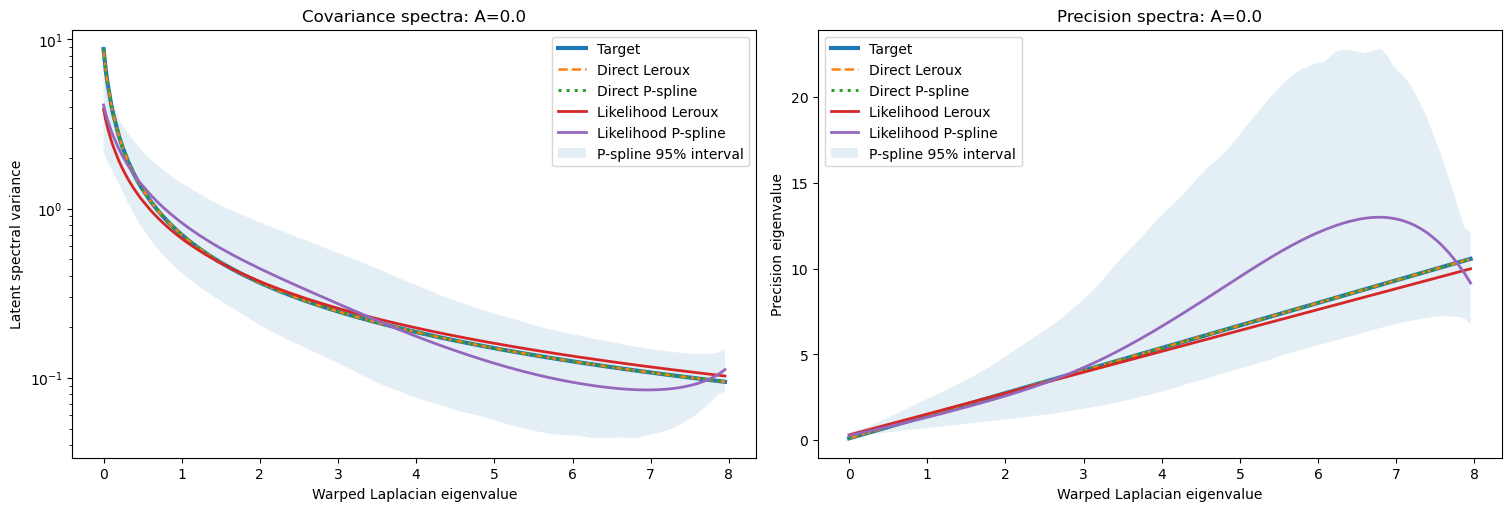

In [59]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5),
    constrained_layout=True,
)

axes[0].plot(
    lam_warp[order],
    target_covariance[order],
    linewidth=3,
    label="Target",
)
axes[0].plot(
    lam_warp[order],
    F_direct_leroux[order],
    linestyle="--",
    linewidth=1.8,
    label="Direct Leroux",
)
axes[0].plot(
    lam_warp[order],
    F_direct_fit[order],
    linestyle=":",
    linewidth=2.2,
    label="Direct P-spline",
)
axes[0].plot(
    lam_warp[order],
    F_leroux_mean[order],
    linewidth=2,
    label="Likelihood Leroux",
)
axes[0].plot(
    lam_warp[order],
    F_pspline_mean[order],
    linewidth=2,
    label="Likelihood P-spline",
)
axes[0].fill_between(
    lam_warp[order],
    F_pspline_lower[order],
    F_pspline_upper[order],
    alpha=0.12,
    label="P-spline 95% interval",
)
axes[0].set_yscale("log")
axes[0].set_xlabel("Warped Laplacian eigenvalue")
axes[0].set_ylabel("Latent spectral variance")
axes[0].set_title(
    f"Covariance spectra: A={AFFINE_SHIFT_A}"
)
axes[0].legend()

axes[1].plot(
    lam_warp[order],
    target_precision[order],
    linewidth=3,
    label="Target",
)
axes[1].plot(
    lam_warp[order],
    q_direct_leroux[order],
    linestyle="--",
    linewidth=1.8,
    label="Direct Leroux",
)
axes[1].plot(
    lam_warp[order],
    q_direct_fit[order],
    linestyle=":",
    linewidth=2.2,
    label="Direct P-spline",
)
axes[1].plot(
    lam_warp[order],
    q_leroux_mean[order],
    linewidth=2,
    label="Likelihood Leroux",
)
axes[1].plot(
    lam_warp[order],
    q_pspline_mean[order],
    linewidth=2,
    label="Likelihood P-spline",
)
axes[1].fill_between(
    lam_warp[order],
    q_pspline_lower[order],
    q_pspline_upper[order],
    alpha=0.12,
    label="P-spline 95% interval",
)
axes[1].set_xlabel("Warped Laplacian eigenvalue")
axes[1].set_ylabel("Precision eigenvalue")
axes[1].set_title(
    f"Precision spectra: A={AFFINE_SHIFT_A}"
)
axes[1].legend()

plt.show()


## 12. Leroux precision versus P-spline affine baseline and nonlinear correction

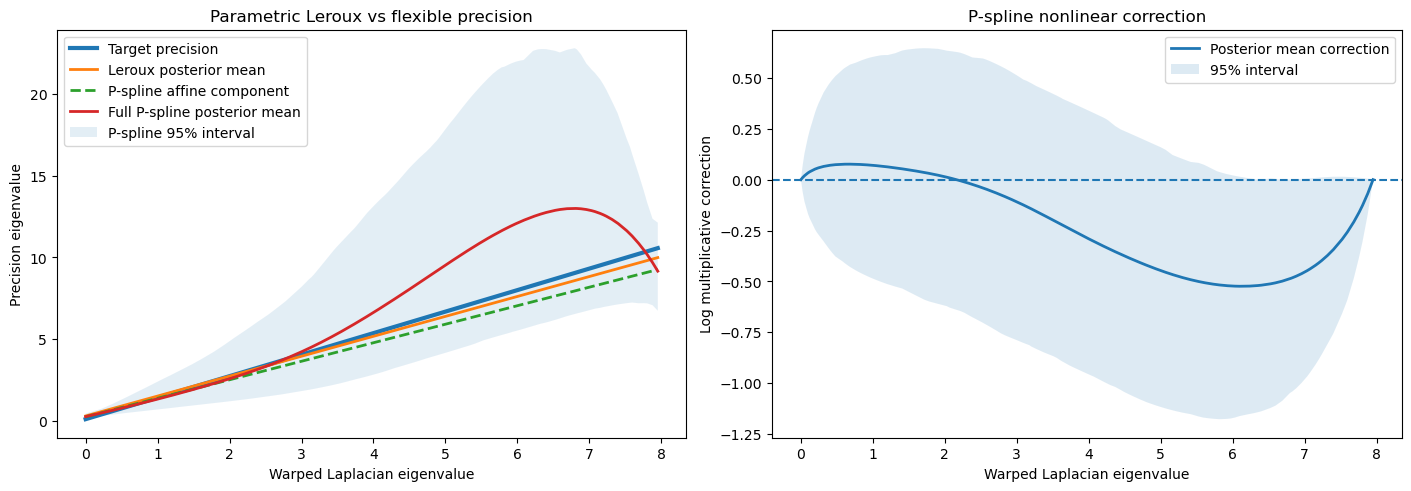

In [60]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 4.8),
    constrained_layout=True,
)

axes[0].plot(
    lam_warp[order],
    target_precision[order],
    linewidth=3,
    label="Target precision",
)

axes[0].plot(
    lam_warp[order],
    q_leroux_mean[order],
    linewidth=2,
    label="Leroux posterior mean",
)

axes[0].plot(
    lam_warp[order],
    q_pspline_affine_mean[order],
    linestyle="--",
    linewidth=2,
    label="P-spline affine component",
)

axes[0].plot(
    lam_warp[order],
    q_pspline_mean[order],
    linewidth=2,
    label="Full P-spline posterior mean",
)

axes[0].fill_between(
    lam_warp[order],
    q_pspline_lower[order],
    q_pspline_upper[order],
    alpha=0.12,
    label="P-spline 95% interval",
)

axes[0].set_xlabel(
    "Warped Laplacian eigenvalue"
)
axes[0].set_ylabel("Precision eigenvalue")
axes[0].set_title(
    "Parametric Leroux vs flexible precision"
)
axes[0].legend()

axes[1].plot(
    lam_warp[order],
    vi_log_correction_mean[order],
    linewidth=2,
    label="Posterior mean correction",
)

axes[1].fill_between(
    lam_warp[order],
    vi_log_correction_lower[order],
    vi_log_correction_upper[order],
    alpha=0.15,
    label="95% interval",
)

axes[1].axhline(
    0.0,
    linestyle="--",
)

axes[1].set_xlabel(
    "Warped Laplacian eigenvalue"
)
axes[1].set_ylabel(
    "Log multiplicative correction"
)
axes[1].set_title(
    "P-spline nonlinear correction"
)
axes[1].legend()

plt.show()


In [61]:
endpoint_table = pd.DataFrame(
    [
        {
            "model": "Target",
            "q_left_mean": target_precision[left],
            "q_left_lower": np.nan,
            "q_left_upper": np.nan,
            "q_right_mean": target_precision[right],
            "q_right_lower": np.nan,
            "q_right_upper": np.nan,
        },
        {
            "model": "Likelihood Leroux",
            "q_left_mean": q_leroux_mean[left],
            "q_left_lower": q_leroux_lower[left],
            "q_left_upper": q_leroux_upper[left],
            "q_right_mean": q_leroux_mean[right],
            "q_right_lower": q_leroux_lower[right],
            "q_right_upper": q_leroux_upper[right],
        },
        {
            "model": "Likelihood P-spline",
            "q_left_mean": q_pspline_mean[left],
            "q_left_lower": q_pspline_lower[left],
            "q_left_upper": q_pspline_upper[left],
            "q_right_mean": q_pspline_mean[right],
            "q_right_lower": q_pspline_lower[right],
            "q_right_upper": q_pspline_upper[right],
        },
    ]
)

display(endpoint_table)

print(
    "Target inside Leroux right-endpoint interval:",
    bool(
        q_leroux_lower[right]
        <= target_precision[right]
        <= q_leroux_upper[right]
    ),
)

print(
    "Target inside P-spline right-endpoint interval:",
    bool(
        q_pspline_lower[right]
        <= target_precision[right]
        <= q_pspline_upper[right]
    ),
)


,model,q_left_mean,q_left_lower,q_left_upper,q_right_mean,q_right_lower,q_right_upper
0,Target,0.114286,NaN,NaN,10.563847,NaN,NaN
1,Likelihood Leroux,0.309567,0.121981,0.626162,9.986206,7.123991,13.218539
2,Likelihood P-spline,0.268306,0.142125,0.462921,9.157227,6.738509,12.120949


Target inside Leroux right-endpoint interval: True
Target inside P-spline right-endpoint interval: True


## 13. Held-out latent-field reconstruction

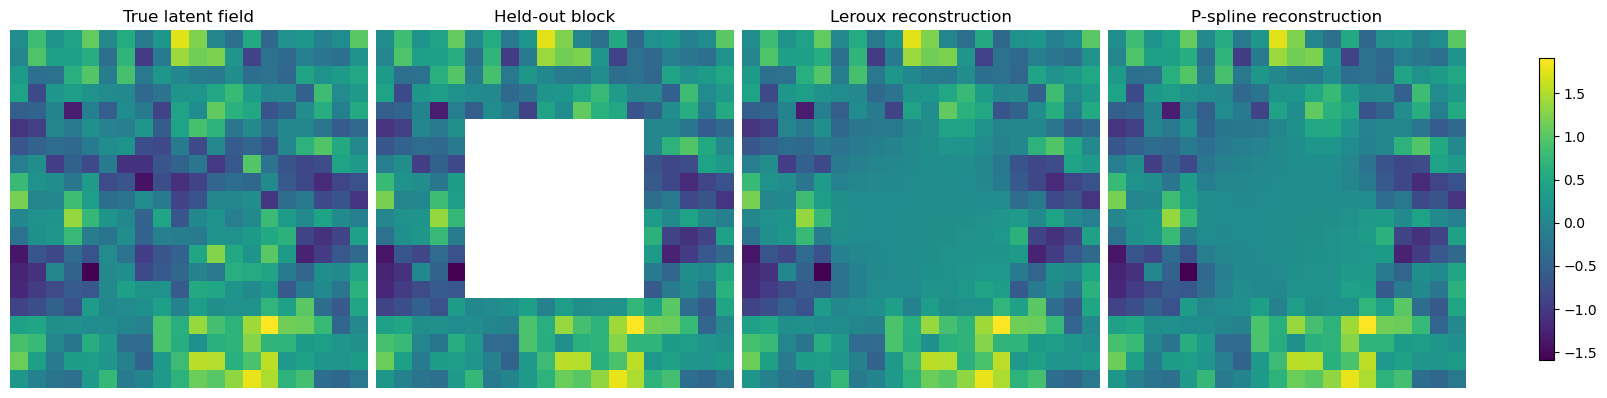

In [62]:
masked = eta_true.copy()
masked[test_mask] = np.nan

leroux_completed = eta_true.copy()
leroux_completed[test_mask] = (
    leroux_prediction_mean
)

pspline_completed = eta_true.copy()
pspline_completed[test_mask] = (
    pspline_prediction_mean
)

fields = [
    eta_true.reshape(N_ROWS, N_COLS),
    masked.reshape(N_ROWS, N_COLS),
    leroux_completed.reshape(N_ROWS, N_COLS),
    pspline_completed.reshape(N_ROWS, N_COLS),
]

titles = [
    "True latent field",
    "Held-out block",
    "Leroux reconstruction",
    "P-spline reconstruction",
]

finite_values = np.concatenate(
    [
        field[np.isfinite(field)]
        for field in fields
    ]
)

vmin = finite_values.min()
vmax = finite_values.max()

fig, axes = plt.subplots(
    1,
    4,
    figsize=(16, 4),
    constrained_layout=True,
)

for ax, field, title in zip(
    axes,
    fields,
    titles,
):
    image = ax.imshow(
        field,
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_title(title)
    ax.axis("off")

fig.colorbar(
    image,
    ax=axes,
    shrink=0.8,
)

plt.show()


## 14. Optimization diagnostics

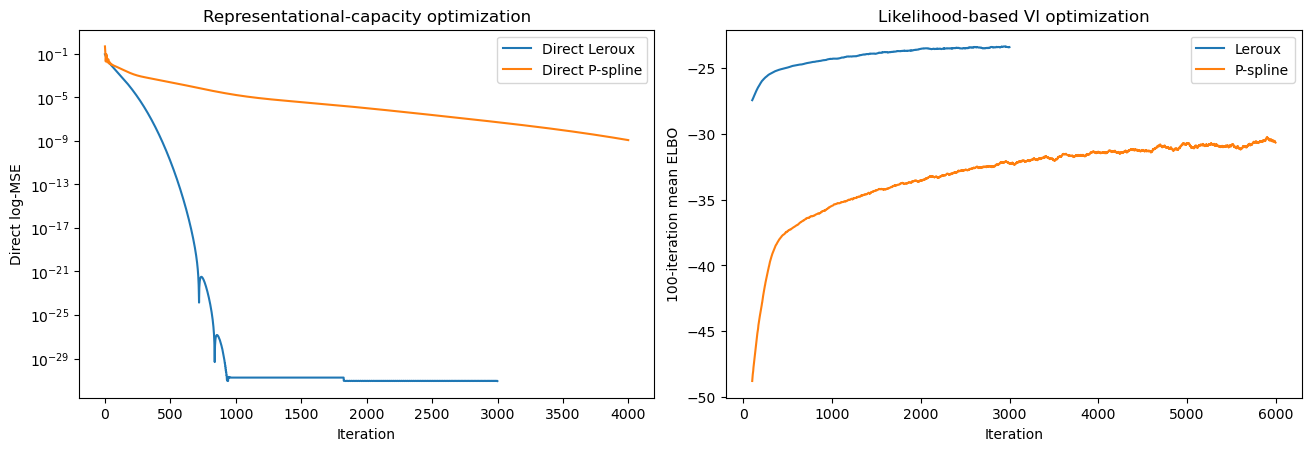

In [63]:
leroux_history = np.asarray(
    leroux_result["history"]
)
pspline_history = np.asarray(
    pspline_result["history"]
)

leroux_smoothed = (
    pd.Series(leroux_history)
    .rolling(100)
    .mean()
)
pspline_smoothed = (
    pd.Series(pspline_history)
    .rolling(100)
    .mean()
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 4.4),
    constrained_layout=True,
)

axes[0].plot(
    direct_leroux_loss_history,
    label="Direct Leroux",
)
axes[0].plot(
    direct_pspline_loss_history,
    label="Direct P-spline",
)
axes[0].set_yscale("log")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Direct log-MSE")
axes[0].set_title(
    "Representational-capacity optimization"
)
axes[0].legend()

axes[1].plot(
    leroux_smoothed,
    label="Leroux",
)
axes[1].plot(
    pspline_smoothed,
    label="P-spline",
)
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel(
    "100-iteration mean ELBO"
)
axes[1].set_title(
    "Likelihood-based VI optimization"
)
axes[1].legend()

plt.show()


## How to interpret the results

The notebook now gives a clean Leroux-versus-SDM comparison under the **same warped operator**.

### At $A=0$

The fitted operator is correct. The target precision is exactly Leroux-affine, so:

* the direct Leroux fit should be essentially exact;
* the direct P-spline should also be essentially exact;
* likelihood-based Leroux should be a strong baseline;
* the P-spline should need little nonlinear correction.

### For $0<A<A_{\mathrm{critical}}$

The transformed positive-mode target is still compatible with an exact Leroux representation in principle. Leroux should remain competitive.

### For $A>A_{\mathrm{critical}}$

An ordinary Leroux model on the warped eigenvalues cannot exactly reproduce the target positive-mode precision. Then compare:

1. **Direct spectrum error.** If the direct P-spline error is much smaller than the direct Leroux error, the flexible family has the required representational advantage.

2. **Likelihood spectrum error.** If the P-spline has the capacity but does not recover it from the data, the limitation is statistical recovery or regularization rather than model-family capacity.

3. **Held-out latent-field RMSE.** Define the RMSE improvement as

$$
G
=

\operatorname{RMSE}_{\eta,\mathrm{Leroux}}

\operatorname{RMSE}_{\eta,\mathrm{P\text{-}spline}}.
$$

Positive $G$ favors the P-spline, while negative $G$ favors Leroux.

4. **Nonlinear correction.** The P-spline affine component gives its global baseline. The learned correction shows how much of the operator misspecification the flexible model actually absorbs.

5. **Endpoint intervals.** Do not judge endpoint recovery only from a plug-in curve. The endpoint table uses Monte Carlo posterior precision summaries,

$$
\mathbb{E}[q(\theta)],
$$

together with corresponding 95% intervals.

For the controlled difficulty sequence, change only:

```python
AFFINE_SHIFT_A = 0.00
AFFINE_SHIFT_A = 0.15
AFFINE_SHIFT_A = 0.50
AFFINE_SHIFT_A = 1.00
AFFINE_SHIFT_A = 2.00
```

Keep the graph, simulated-data seed, holdout, model initializations, priors, and optimization settings fixed.


In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

# ---------------------------------------------------------
# Configuration for the Breakdown Curve
# ---------------------------------------------------------
A_VALUES = [0.0, 0.2, 0.4, 0.8, 1.2]
TRIAL_SEEDS = [100, 101, 102, 103, 104]  # 5 trials per shift for demonstration. 
                                         # Increase to 30+ for formal publication.

breakdown_results = []
A_CRITICAL = (1.0 - RHO_TRUE) / RHO_TRUE

print(f"Starting Monte Carlo trials. Theoretical threshold: A = {A_CRITICAL:.3f}")

for A in A_VALUES:
    print(f"\n{'='*50}\nRunning Spatial Fits for Affine Shift A = {A}\n{'='*50}")
    
    # 1. Warp the spectrum for the current A
    lam_warp_current = affine_shift_positive_modes(
        lam_true,
        shift=A,
        scale=AFFINE_SCALE_B,
    )
    lam_warp_t, U_warp_t = graph_tensors(lam_warp_current, U_warp)
    
    for seed in TRIAL_SEEDS:
        # 2. Simulate a fresh realization of the latent field and response
        rng_trial = np.random.default_rng(seed)
        
        phi_trial = U_true @ (np.sqrt(target_covariance) * rng_trial.normal(size=N))
        eta_trial = BETA_TRUE + phi_trial
        y_trial = eta_trial + rng_trial.normal(loc=0.0, scale=np.sqrt(SIGMA2_TRUE), size=N)
        
        # 3. Prepare the PyTorch tensors for the VI pipeline
        y_all_t = torch.tensor(y_trial, dtype=torch.double, device=DEVICE)
        y_test_t = y_all_t[is_holdout_t].clone()
        
        # Apply the central holdout mask
        y_fit_t = y_all_t.clone()
        y_fit_t[is_holdout_t] = torch.nan
        
        # 4. Fit the rigid Leroux CAR baseline
        leroux_result = fit_spectral_vi(
            label=f"Leroux (A={A}, Seed={seed})",
            lam_t=lam_warp_t,
            U_t=U_warp_t,
            filter_module=make_leroux_filter(),
            iterations=LEROUX_ITERS,
            learning_rate=LEROUX_LR,
            seed=seed,
        )
        
        # 5. Fit the flexible P-spline SDM-CAR
        pspline_result = fit_spectral_vi(
            label=f"P-spline (A={A}, Seed={seed})",
            lam_t=lam_warp_t,
            U_t=U_warp_t,
            filter_module=make_precision_spline_filter(lam_warp_t),
            iterations=PSPLINE_ITERS,
            learning_rate=PSPLINE_LR,
            seed=seed,
        )
        
        # 6. Extract predictions and score against the true masked eta_trial
        leroux_pred = leroux_result["prediction"]["mean"].detach().cpu().numpy()
        pspline_pred = pspline_result["prediction"]["mean"].detach().cpu().numpy()
        
        leroux_rmse = float(np.sqrt(np.mean((leroux_pred - eta_trial[test_mask]) ** 2)))
        pspline_rmse = float(np.sqrt(np.mean((pspline_pred - eta_trial[test_mask]) ** 2)))
        
        # 7. Log metrics
        breakdown_results.append({
            "A": A,
            "Seed": seed,
            "Model": "Leroux CAR",
            "Latent_RMSE": leroux_rmse
        })
        breakdown_results.append({
            "A": A,
            "Seed": seed,
            "Model": "Precision P-spline SDM-CAR",
            "Latent_RMSE": pspline_rmse
        })

df_breakdown = pd.DataFrame(breakdown_results)
print("\nTrials complete. Ready for visualization.")

Starting Monte Carlo trials. Theoretical threshold: A = 0.087

Running Spatial Fits for Affine Shift A = 0.0
Leroux (A=0.0, Seed=100): 500/3000, recent ELBO=-49.175
Leroux (A=0.0, Seed=100): 1000/3000, recent ELBO=-48.468
Leroux (A=0.0, Seed=100): 1500/3000, recent ELBO=-48.041
Leroux (A=0.0, Seed=100): 2000/3000, recent ELBO=-47.853
Leroux (A=0.0, Seed=100): 2500/3000, recent ELBO=-47.632
Leroux (A=0.0, Seed=100): 3000/3000, recent ELBO=-47.692
P-spline (A=0.0, Seed=100): 500/6000, recent ELBO=-61.040
P-spline (A=0.0, Seed=100): 1000/6000, recent ELBO=-59.741
P-spline (A=0.0, Seed=100): 1500/6000, recent ELBO=-58.894
P-spline (A=0.0, Seed=100): 2000/6000, recent ELBO=-58.305
P-spline (A=0.0, Seed=100): 2500/6000, recent ELBO=-57.472
P-spline (A=0.0, Seed=100): 3000/6000, recent ELBO=-57.081
P-spline (A=0.0, Seed=100): 3500/6000, recent ELBO=-56.876
P-spline (A=0.0, Seed=100): 4000/6000, recent ELBO=-56.492
P-spline (A=0.0, Seed=100): 4500/6000, recent ELBO=-56.407
P-spline (A=0.0, See

C:\Users\pd006\AppData\Local\Temp\ipykernel_5708\3877981495.py:27: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-s" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(


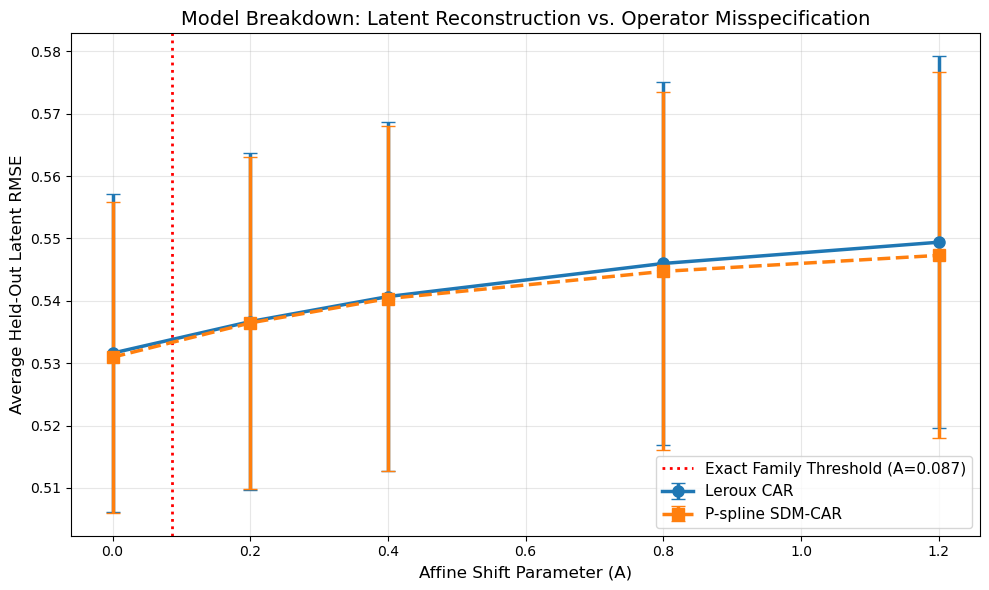

Model,Leroux CAR,Precision P-spline SDM-CAR
A,,
0.0,0.531620,0.530966
0.2,0.536676,0.536461
0.4,0.540686,0.540366
0.8,0.545996,0.544725
1.2,0.549400,0.547293


In [65]:
# ---------------------------------------------------------
# Plotting the Breakdown Curve
# ---------------------------------------------------------
# Calculate the mean and standard error of Latent RMSE across seeds
summary_df = df_breakdown.groupby(["A", "Model"])["Latent_RMSE"].agg(['mean', 'std']).reset_index()
summary_df['se'] = summary_df['std'] / np.sqrt(len(TRIAL_SEEDS))

plt.figure(figsize=(10, 6))

# Filter data by model
leroux_data = summary_df[summary_df["Model"] == "Leroux CAR"]
pspline_data = summary_df[summary_df["Model"] == "Precision P-spline SDM-CAR"]

# Plot Leroux baseline
plt.errorbar(
    leroux_data["A"], 
    leroux_data["mean"], 
    yerr=leroux_data["se"], 
    label="Leroux CAR", 
    fmt='-o', 
    linewidth=2.5, 
    markersize=8,
    capsize=5
)

# Plot flexible P-spline
plt.errorbar(
    pspline_data["A"], 
    pspline_data["mean"], 
    yerr=pspline_data["se"], 
    label="P-spline SDM-CAR", 
    fmt='-s', 
    linewidth=2.5,
    markersize=8,
    linestyle='--',
    capsize=5
)

# Overlay the theoretical threshold where Leroux breaks down
plt.axvline(
    x=A_CRITICAL, 
    color='red', 
    linestyle=':', 
    linewidth=2,
    label=f'Exact Family Threshold (A={A_CRITICAL:.3f})'
)

# Formatting
plt.title("Model Breakdown: Latent Reconstruction vs. Operator Misspecification", fontsize=14)
plt.xlabel("Affine Shift Parameter (A)", fontsize=12)
plt.ylabel("Average Held-Out Latent RMSE", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

# Display the aggregated numbers for exact reference
display(summary_df.pivot(index='A', columns='Model', values='mean'))

In [68]:
def calculate_empirical_coverage(prediction_dict, true_values, mask, credible_level=0.95):
    """
    Calculates the percentage of true held-out values that fall within 
    the model's predictive credible interval.
    """
    tail = (1.0 - credible_level) / 2.0
    
    # Extract only the true values for the held-out block (size 100)
    true_heldout = true_values[mask]
    
    if "draws" in prediction_dict:
        # The model already returns draws only for the held-out nodes (shape: [num_mc, 100])
        heldout_draws = prediction_dict["draws"].detach().cpu().numpy()
        lower_bound = np.quantile(heldout_draws, tail, axis=0)
        upper_bound = np.quantile(heldout_draws, 1.0 - tail, axis=0)
    elif "lower" in prediction_dict and "upper" in prediction_dict:
        # The model already returns bounds only for the held-out nodes (shape: [100])
        lower_bound = prediction_dict["lower"].detach().cpu().numpy()
        upper_bound = prediction_dict["upper"].detach().cpu().numpy()
    else:
        raise KeyError("Prediction dictionary must contain 'draws' or 'lower'/'upper' keys.")
        
    coverage = np.mean((true_heldout >= lower_bound) & (true_heldout <= upper_bound))
    return float(coverage)

In [69]:
# ---------------------------------------------------------
# Configuration for the Breakdown Curve (Coverage + RMSE)
# ---------------------------------------------------------
A_VALUES = [0.0, 0.2, 0.4, 0.8, 1.2]
TRIAL_SEEDS = [100, 101, 102, 103, 104] 

breakdown_results = []
A_CRITICAL = (1.0 - RHO_TRUE) / RHO_TRUE

print(f"Starting Monte Carlo trials. Theoretical threshold: A = {A_CRITICAL:.3f}")

for A in A_VALUES:
    print(f"\n{'='*50}\nRunning Spatial Fits for Affine Shift A = {A}\n{'='*50}")
    
    lam_warp_current = affine_shift_positive_modes(lam_true, shift=A, scale=AFFINE_SCALE_B)
    lam_warp_t, U_warp_t = graph_tensors(lam_warp_current, U_warp)
    
    for seed in TRIAL_SEEDS:
        rng_trial = np.random.default_rng(seed)
        
        phi_trial = U_true @ (np.sqrt(target_covariance) * rng_trial.normal(size=N))
        eta_trial = BETA_TRUE + phi_trial
        y_trial = eta_trial + rng_trial.normal(loc=0.0, scale=np.sqrt(SIGMA2_TRUE), size=N)
        
        y_all_t = torch.tensor(y_trial, dtype=torch.double, device=DEVICE)
        y_test_t = y_all_t[is_holdout_t].clone()
        
        y_fit_t = y_all_t.clone()
        y_fit_t[is_holdout_t] = torch.nan
        
        # Fit Leroux
        leroux_result = fit_spectral_vi(
            label=f"Leroux (A={A}, Seed={seed})",
            lam_t=lam_warp_t, U_t=U_warp_t,
            filter_module=make_leroux_filter(),
            iterations=LEROUX_ITERS, learning_rate=LEROUX_LR, seed=seed,
        )
        
        # Fit P-spline
        pspline_result = fit_spectral_vi(
            label=f"P-spline (A={A}, Seed={seed})",
            lam_t=lam_warp_t, U_t=U_warp_t,
            filter_module=make_precision_spline_filter(lam_warp_t),
            iterations=PSPLINE_ITERS, learning_rate=PSPLINE_LR, seed=seed,
        )
        
        # Extract coverage metrics
        leroux_coverage = calculate_empirical_coverage(
            leroux_result["prediction"], eta_trial, test_mask
        )
        pspline_coverage = calculate_empirical_coverage(
            pspline_result["prediction"], eta_trial, test_mask
        )
        
        breakdown_results.append({
            "A": A, "Seed": seed,
            "Model": "Leroux CAR",
            "Coverage_Rate": leroux_coverage
        })
        breakdown_results.append({
            "A": A, "Seed": seed,
            "Model": "Precision P-spline SDM-CAR",
            "Coverage_Rate": pspline_coverage
        })

df_coverage = pd.DataFrame(breakdown_results)
print("\nCoverage Trials complete.")

Starting Monte Carlo trials. Theoretical threshold: A = 0.087

Running Spatial Fits for Affine Shift A = 0.0
Leroux (A=0.0, Seed=100): 500/3000, recent ELBO=-49.175
Leroux (A=0.0, Seed=100): 1000/3000, recent ELBO=-48.468
Leroux (A=0.0, Seed=100): 1500/3000, recent ELBO=-48.041
Leroux (A=0.0, Seed=100): 2000/3000, recent ELBO=-47.853
Leroux (A=0.0, Seed=100): 2500/3000, recent ELBO=-47.632
Leroux (A=0.0, Seed=100): 3000/3000, recent ELBO=-47.692
P-spline (A=0.0, Seed=100): 500/6000, recent ELBO=-61.040
P-spline (A=0.0, Seed=100): 1000/6000, recent ELBO=-59.741
P-spline (A=0.0, Seed=100): 1500/6000, recent ELBO=-58.894
P-spline (A=0.0, Seed=100): 2000/6000, recent ELBO=-58.305
P-spline (A=0.0, Seed=100): 2500/6000, recent ELBO=-57.472
P-spline (A=0.0, Seed=100): 3000/6000, recent ELBO=-57.081
P-spline (A=0.0, Seed=100): 3500/6000, recent ELBO=-56.876
P-spline (A=0.0, Seed=100): 4000/6000, recent ELBO=-56.492
P-spline (A=0.0, Seed=100): 4500/6000, recent ELBO=-56.407
P-spline (A=0.0, See

C:\Users\pd006\AppData\Local\Temp\ipykernel_5708\4274065846.py:17: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-s" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(


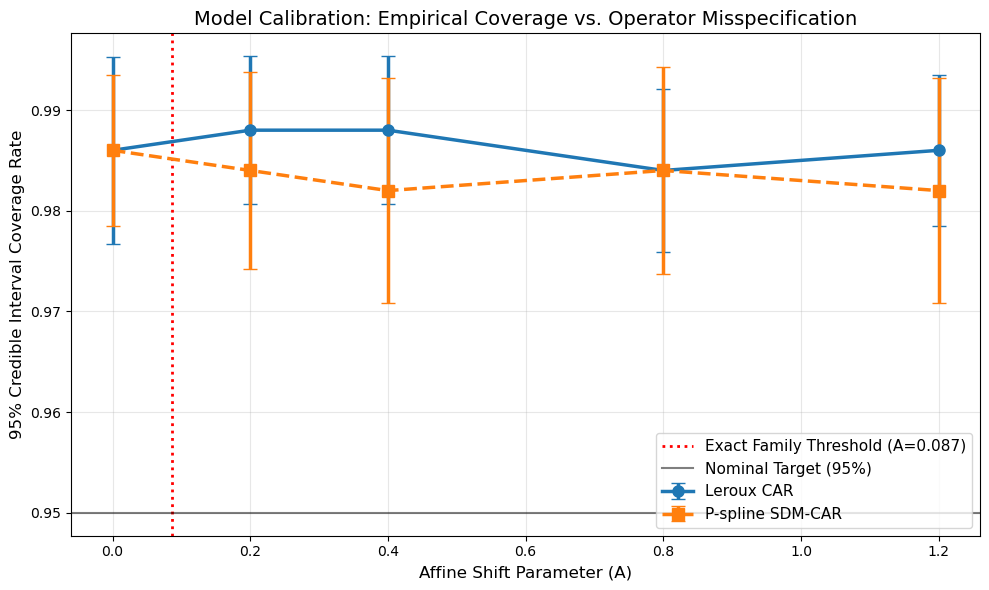

Model,Leroux CAR,Precision P-spline SDM-CAR
A,,
0.0,0.986,0.986
0.2,0.988,0.984
0.4,0.988,0.982
0.8,0.984,0.984
1.2,0.986,0.982


In [71]:
# ---------------------------------------------------------
# Plotting the Coverage Calibration
# ---------------------------------------------------------
summary_cov = df_coverage.groupby(["A", "Model"])["Coverage_Rate"].agg(['mean', 'std']).reset_index()
summary_cov['se'] = summary_cov['std'] / np.sqrt(len(TRIAL_SEEDS))

plt.figure(figsize=(10, 6))

leroux_data = summary_cov[summary_cov["Model"] == "Leroux CAR"]
pspline_data = summary_cov[summary_cov["Model"] == "Precision P-spline SDM-CAR"]

plt.errorbar(
    leroux_data["A"], leroux_data["mean"], yerr=leroux_data["se"], 
    label="Leroux CAR", fmt='-o', linewidth=2.5, markersize=8, capsize=5
)

plt.errorbar(
    pspline_data["A"], pspline_data["mean"], yerr=pspline_data["se"], 
    label="P-spline SDM-CAR", fmt='-s', linewidth=2.5, markersize=8, 
    linestyle='--', capsize=5
)

# Overlay the theoretical threshold
plt.axvline(
    x=A_CRITICAL, color='red', linestyle=':', linewidth=2,
    label=f'Exact Family Threshold (A={A_CRITICAL:.3f})'
)

# Overlay the nominal 95% target line
plt.axhline(
    y=0.95, color='black', linestyle='-', alpha=0.5, linewidth=1.5,
    label='Nominal Target (95%)'
)

plt.title("Model Calibration: Empirical Coverage vs. Operator Misspecification", fontsize=14)
plt.xlabel("Affine Shift Parameter (A)", fontsize=12)
plt.ylabel("95% Credible Interval Coverage Rate", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

display(summary_cov.pivot(index='A', columns='Model', values='mean'))